# Zadanie 2. Choroba wątroby

Plik `liver.csv` zawiera informacje o pacjentach, z których część zdiagnozowano jako osoby chore na wątrobę, a pozostałe jako zdrowe. Informacja o przynależności pacjenta do jednej z dwóch grup znajduje się w zmiennej `Selector`, która pełni funkcję etykiety klasy (targetu/celu) w problemie klasyfikacyjnym.


Celem analizy jest budowa modelu klasyfikacyjnego `GradientBoostingClassifier` do rozpoznawania przypadków choroby wątroby. Zbudowany model uruchamiany na danych testowych z pliku `liver_test.csv`, a wynik zapisywany do pliku `w.csv` w kolumnie `Selector`.

## Import bibliotek

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

## Wczytanie danych

In [184]:
df = pd.read_csv('liver.csv')
df_test = pd.read_csv('liver_test.csv')
print('Zbiór treningowy:', df.shape)
print('Zbiór testowy:   ', df_test.shape)

Zbiór treningowy: (483, 11)
Zbiór testowy:    (100, 10)


In [185]:
df.head(10)

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,50,Male,4.2,2.3,450,69,50,7.0,3.0,0.7,1
1,38,Female,0.6,0.1,165,22,34,5.9,2.9,0.9,2
2,75,Female,0.8,0.2,188,20,29,4.4,1.8,0.6,1
3,72,Male,0.7,0.1,196,20,35,5.8,2.0,0.5,1
4,40,Female,2.1,1.0,768,74,141,7.8,4.9,1.6,1
5,48,Male,0.7,0.2,208,15,30,4.6,2.1,0.8,2
6,37,Male,1.8,0.8,145,62,58,5.7,2.9,1.0,1
7,21,Male,0.8,0.2,183,33,57,6.8,3.5,1.0,2
8,46,Male,1.8,0.7,208,19,14,7.6,4.4,1.3,1
9,50,Male,1.2,0.4,282,36,32,7.2,3.9,1.1,1


## Eksploracja danych

In [186]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 483 entries, 0 to 482
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        483 non-null    int64  
 1   Gender     483 non-null    str    
 2   TB         483 non-null    float64
 3   DB         483 non-null    float64
 4   Alkphos    483 non-null    int64  
 5   Sgpt       483 non-null    int64  
 6   Sgot       483 non-null    int64  
 7   TP         483 non-null    float64
 8   ALB        483 non-null    float64
 9   A/G Ratio  480 non-null    float64
 10  Selector   483 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 41.6 KB


In [187]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        100 non-null    int64  
 1   Gender     100 non-null    str    
 2   TB         100 non-null    float64
 3   DB         100 non-null    float64
 4   Alkphos    100 non-null    int64  
 5   Sgpt       100 non-null    int64  
 6   Sgot       100 non-null    int64  
 7   TP         100 non-null    float64
 8   ALB        100 non-null    float64
 9   A/G Ratio  99 non-null     float64
dtypes: float64(5), int64(4), str(1)
memory usage: 7.9 KB


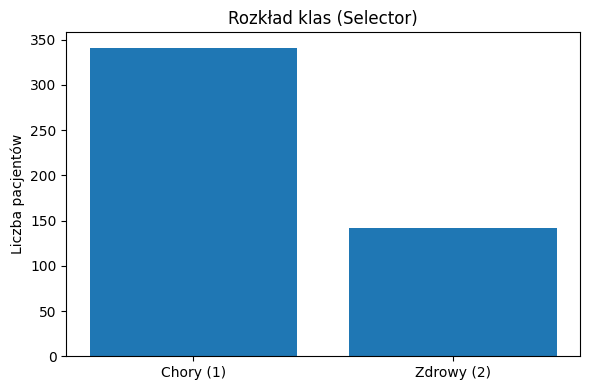

Stosunek klas: 2.40 (chory/zdrowy)


In [188]:
# Rozkład klas
class_counts = df['Selector'].value_counts()
labels = ['Chory (1)', 'Zdrowy (2)']

plt.figure(figsize=(6, 4))

bars = plt.bar(labels, class_counts.values)

plt.ylabel('Liczba pacjentów')
plt.title('Rozkład klas (Selector)')
plt.tight_layout()
plt.show()

print(f'Stosunek klas: {class_counts[1]/class_counts[2]:.2f} (chory/zdrowy)')

## Analiza eksploracyjna

### Rozkład zmiennych według płci

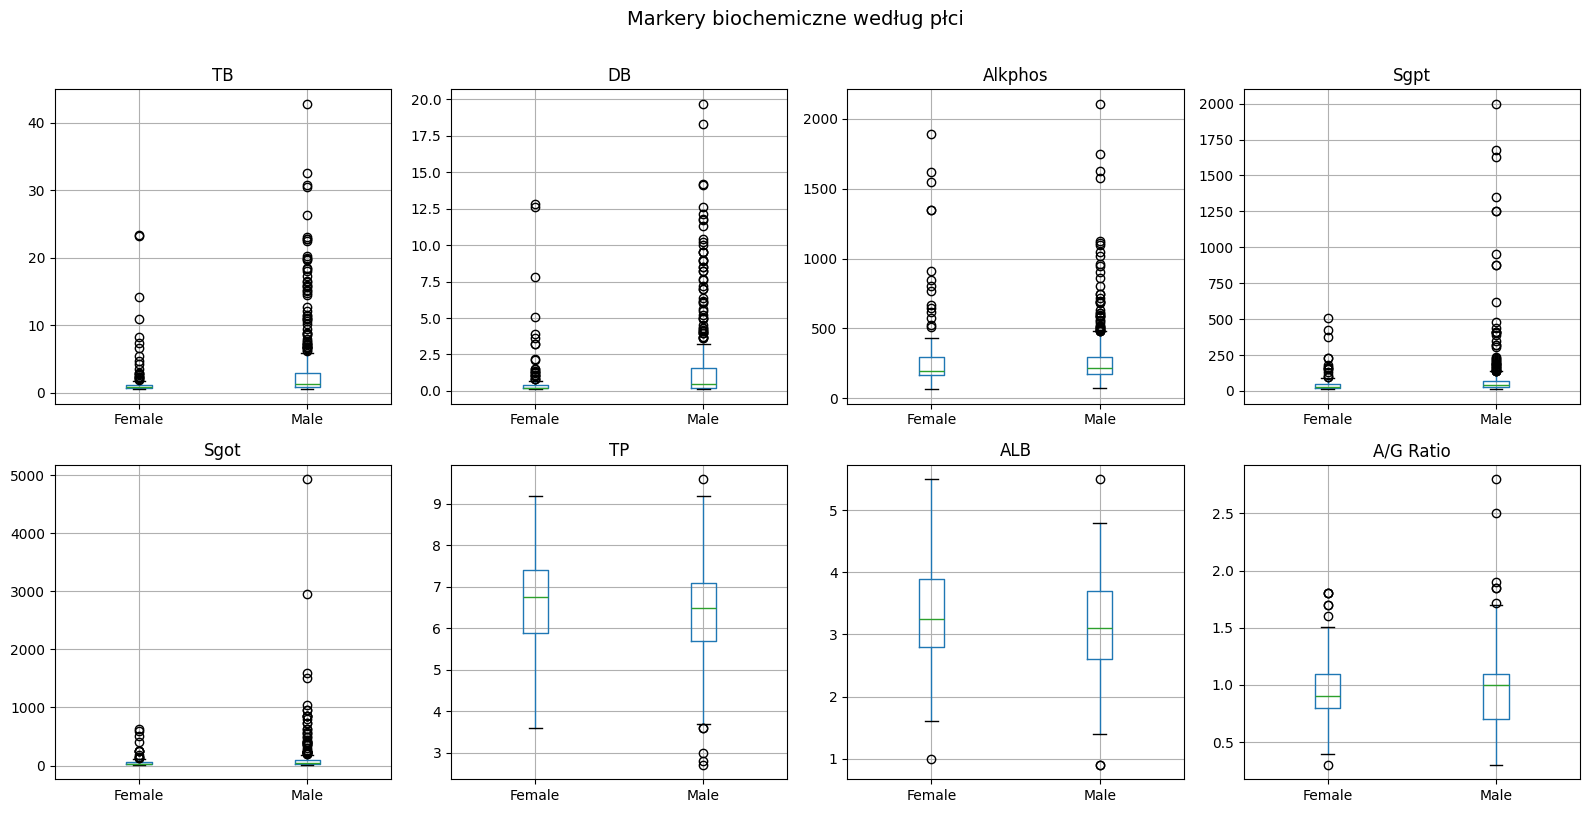

In [189]:
bio_cols = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()


for i, col in enumerate(bio_cols):
    df.boxplot(column=col, by='Gender', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    
    
plt.suptitle('Markery biochemiczne według płci', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

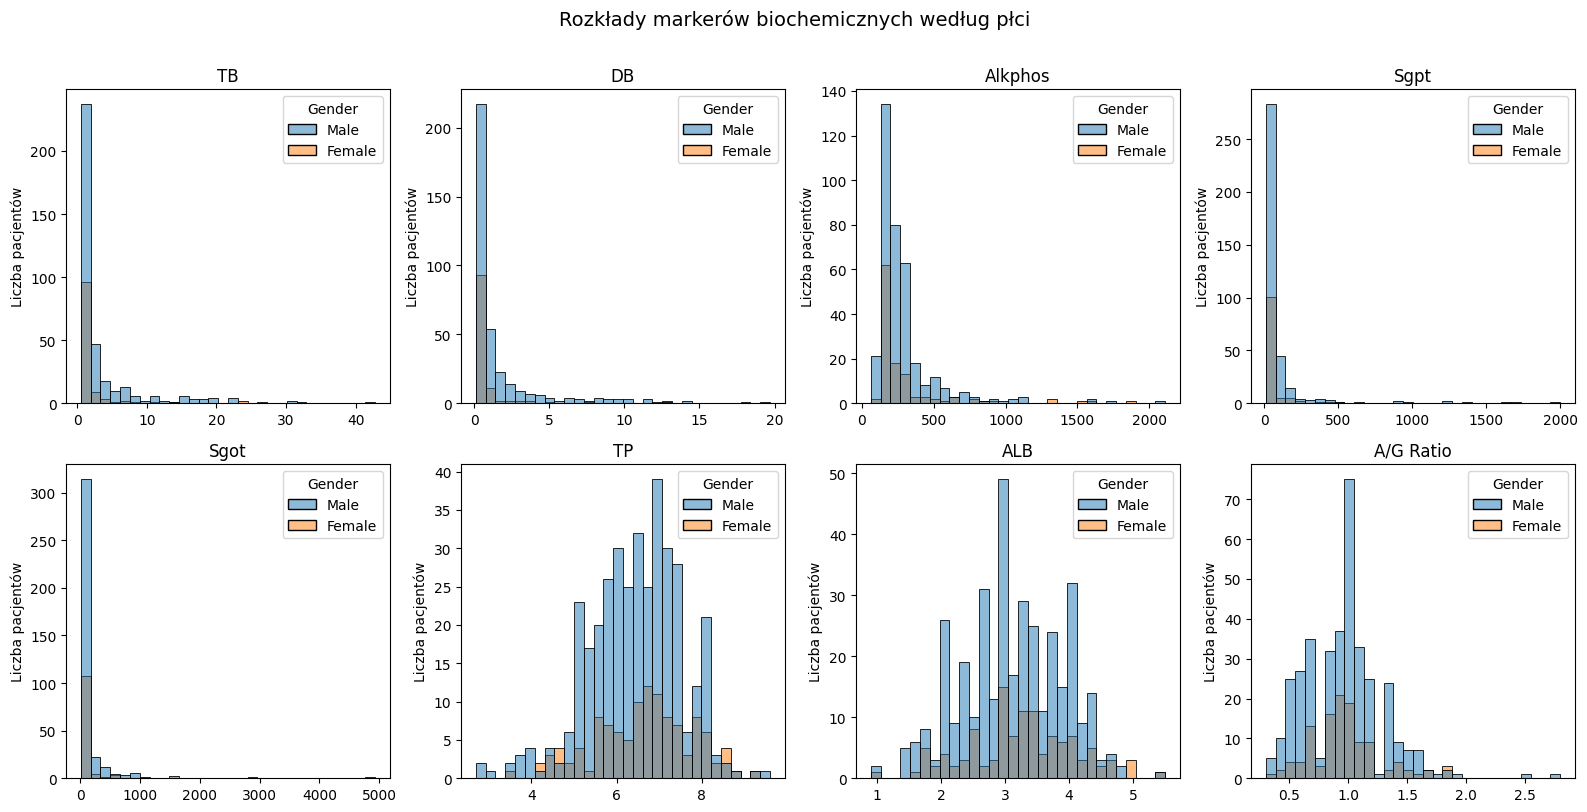

In [190]:
bio_cols = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(bio_cols):
    sns.histplot(data=df, x=col, hue='Gender', ax=axes[i], bins=30)
    
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Liczba pacjentów')


plt.suptitle('Rozkłady markerów biochemicznych według płci', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Markery biochemiczne: chorzy vs. zdrowi

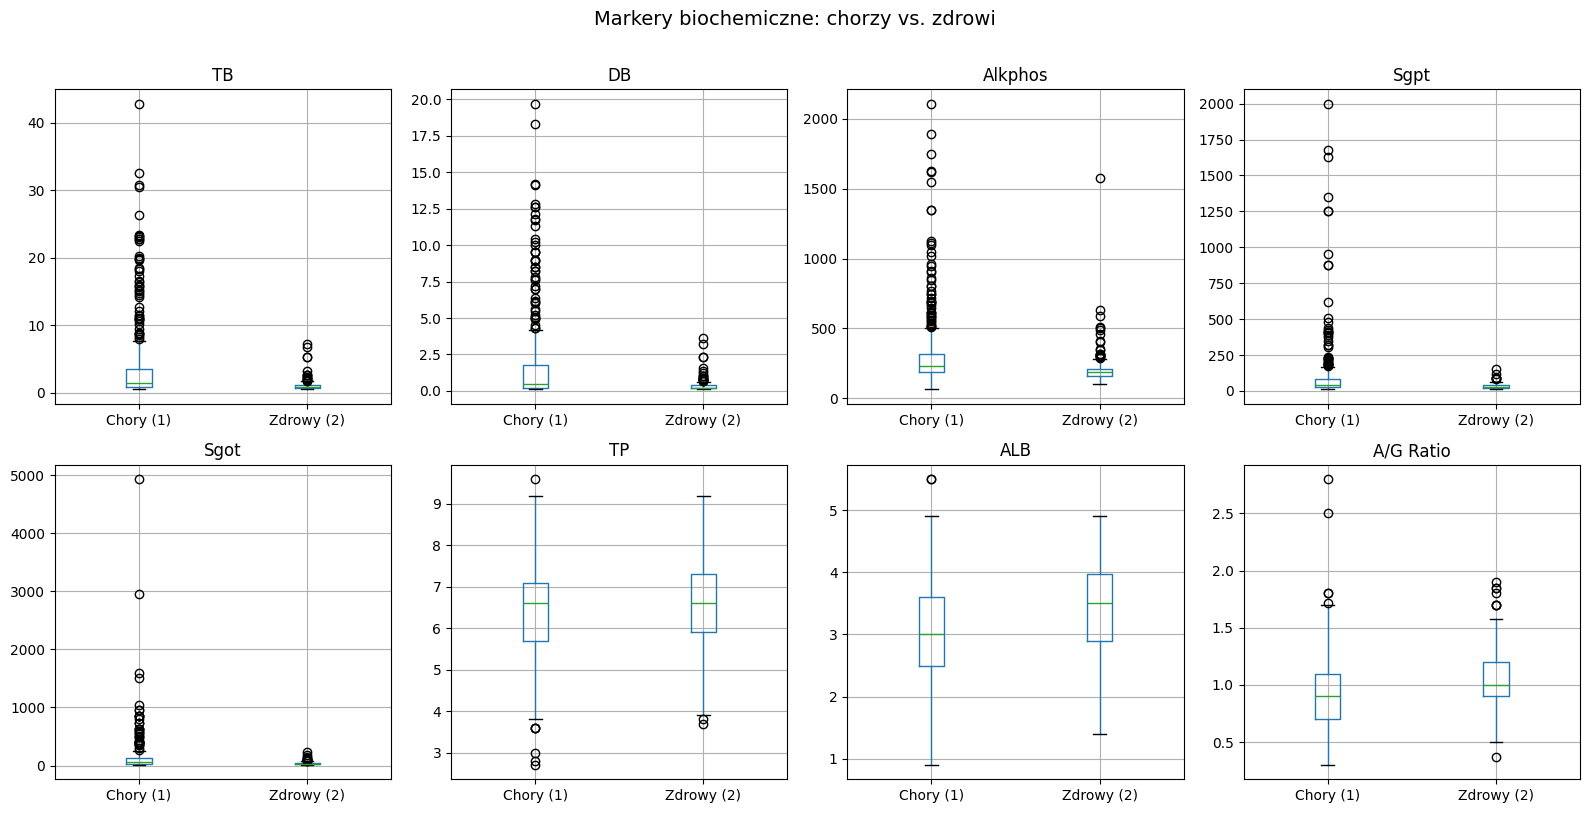

In [191]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()


for i, col in enumerate(bio_cols):
    df.boxplot(column=col, by='Selector', ax=axes[i])
    axes[i].set_xticklabels(['Chory (1)', 'Zdrowy (2)'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    
    
plt.suptitle('Markery biochemiczne: chorzy vs. zdrowi', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

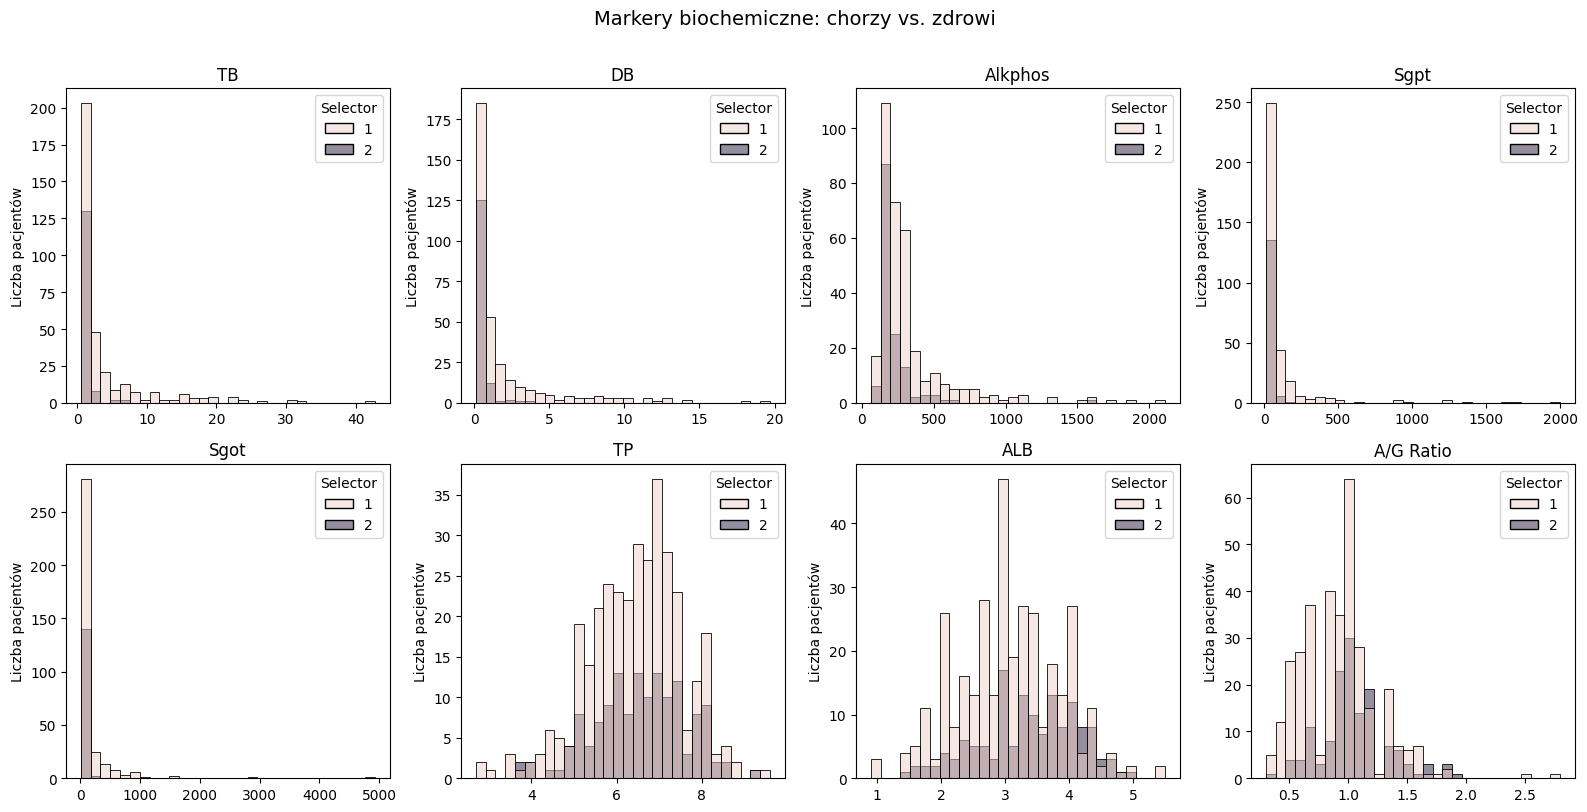

In [192]:
bio_cols = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(bio_cols):
    sns.histplot(data=df, x=col, hue='Selector', ax=axes[i], bins=30)
    
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Liczba pacjentów')


plt.suptitle('Markery biochemiczne: chorzy vs. zdrowi', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Skuteczność przewidywania według płci

In [193]:
print('Rozkład klas według płci:')
print(df.groupby(['Gender', 'Selector']).size().unstack(fill_value=0))

Rozkład klas według płci:
Selector    1    2
Gender            
Female     74   42
Male      267  100


In [194]:
bio_cols_outliers = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot']

def iqr_count(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5*iqr
    hi = q3 + 1.5*iqr
    count = 0
    
    for x in s:
        if x < lo or x > hi:
            count += 1
    return count

print('Outliery:')
for col in bio_cols_outliers:
    print(f'{col}: {iqr_count(df[col])}')

Outliery:
TB: 68
DB: 65
Alkphos: 54
Sgpt: 61
Sgot: 59


In [195]:
df_clip = df.copy()
df_test_clip = df_test.copy()


for col in bio_cols_outliers:
    df_clip[col] = np.log1p(df_clip[col])
    df_test_clip[col] = np.log1p(df_test_clip[col])


for col in bio_cols_outliers:
    q1 = df_clip[col].quantile(0.25)
    q3 = df_clip[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5*iqr
    hi = q3 + 1.5*iqr
    
    df_clip[col] = df_clip[col].clip(lower=lo, upper=hi)
    df_test_clip[col] = df_test_clip[col].clip(lower=lo, upper=hi)

print('Outliery po transformacji')
for col in bio_cols_outliers:
    print(f'  {col}: {iqr_count(df_clip[col])}')

Outliery po transformacji
  TB: 0
  DB: 0
  Alkphos: 0
  Sgpt: 0
  Sgot: 0


In [196]:
print('Duplikaty w zbiorze treningowym:', df_clip.duplicated().sum())
print('Duplikaty w zbiorze testowym:   ', df_test_clip.duplicated().sum())


before = len(df_clip)
df_clip = df_clip.drop_duplicates().reset_index(drop=True)
print(f'Po usunieciu: z {before} zostało {len(df_clip)} wierszy')

Duplikaty w zbiorze treningowym: 8
Duplikaty w zbiorze testowym:    0
Po usunieciu: z 483 zostało 475 wierszy


In [197]:
# Sprawdzenie wartosci kategorycznych
print('Gender (trening):', df_clip['Gender'].unique())
print('Gender (test):   ', df_test_clip['Gender'].unique())
print('Selector (trening):', sorted(df_clip['Selector'].unique()))

Gender (trening): <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Gender (test):    <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Selector (trening): [np.int64(1), np.int64(2)]


In [198]:
df = df_clip
df_test = df_test_clip

## Przygotowanie danych

In [199]:
gender_mapping = {'Male': 1, 'Female': 0}


def preprocess(data):
    df_proc = data.copy()

    fill_median = df_proc['A/G Ratio'].median()
    df_proc['A/G Ratio'] = df_proc['A/G Ratio'].fillna(fill_median)


    df_proc['Gender'] = df_proc['Gender'].map(gender_mapping)

    return df_proc

df_proc = preprocess(df)
df_test_proc = preprocess(df_test)

print('Przetworzone dane treningowe:', df_proc.shape)
print('Brakujące wartości:', df_proc.isnull().sum().sum())

print('Przetworzone dane testowe:', df_test_proc.shape)
print('Brakujące wartości:', df_test_proc.isnull().sum().sum())

Przetworzone dane treningowe: (475, 11)
Brakujące wartości: 0
Przetworzone dane testowe: (100, 10)
Brakujące wartości: 0


In [200]:
feature_cols = []
for c in df_proc.columns:
    if c != 'Selector':
        feature_cols.append(c)


X = df_proc[feature_cols]
y = df_proc['Selector']
X_pred = df_test_proc[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [201]:
df_proc.info()

<class 'pandas.DataFrame'>
RangeIndex: 475 entries, 0 to 474
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        475 non-null    int64  
 1   Gender     475 non-null    int64  
 2   TB         475 non-null    float64
 3   DB         475 non-null    float64
 4   Alkphos    475 non-null    float64
 5   Sgpt       475 non-null    float64
 6   Sgot       475 non-null    float64
 7   TP         475 non-null    float64
 8   ALB        475 non-null    float64
 9   A/G Ratio  475 non-null    float64
 10  Selector   475 non-null    int64  
dtypes: float64(8), int64(3)
memory usage: 40.9 KB


## Model GradientBoostingClassifier

### Model bazowy

In [202]:
gbc_base = GradientBoostingClassifier(random_state=42)
gbc_base.fit(X_train, y_train)
y_pred_base = gbc_base.predict(X_val)
acc_base = accuracy_score(y_val, y_pred_base)
print(f'Accuracy modelu bazowego: {acc_base:.4f}')

Accuracy modelu bazowego: 0.7053


### Strojenie hiperparametrów (RandomizedSearchCV)

In [203]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [1, 2, 3, 5]
}


gbc = GradientBoostingClassifier(random_state=42)

rand_search = RandomizedSearchCV(gbc, params, n_iter=80, scoring='accuracy', cv=5, random_state=42)
rand_search.fit(X_train, y_train)

best_params = rand_search.best_params_
best_cv_acc = rand_search.best_score_
print('Najlepsze parametry:', best_params)
print(f'CV Accuracy (treningowy): {best_cv_acc:.4f}')

Najlepsze parametry: {'subsample': 0.6, 'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.2}
CV Accuracy (treningowy): 0.6974


In [204]:
best_model = rand_search.best_estimator_
y_pred_val = best_model.predict(X_val)
acc_val = accuracy_score(y_val, y_pred_val)
print(f'Accuracy na zbiorze walidacyjnym: {acc_val:.4f}')

Accuracy na zbiorze walidacyjnym: 0.6842


### Macierz pomyłek

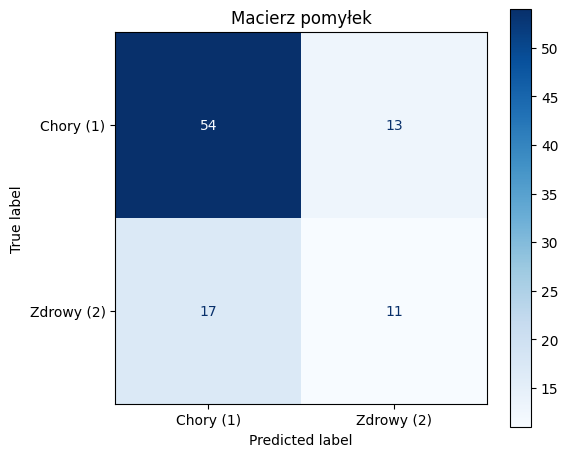

In [205]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val, display_labels=['Chory (1)', 'Zdrowy (2)'], cmap='Blues', ax=ax)
plt.title('Macierz pomyłek')
plt.tight_layout()
plt.show()

### Analiza wpływu płci na skuteczność klasyfikacji

     Płeć  Accuracy  Liczba
Mężczyźni  0.695652      69
  Kobiety  0.653846      26


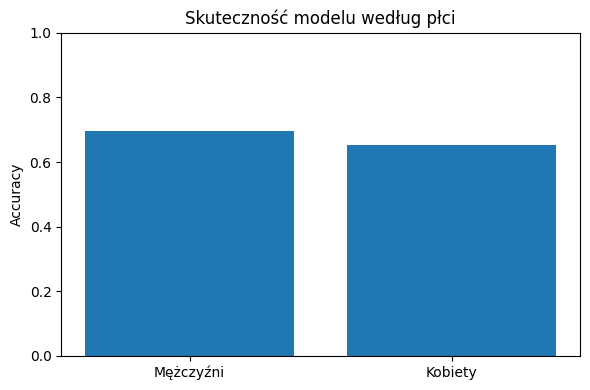

In [206]:
# Predykcja na zbiorze walidacyjnym z podzialem na plec
X_val_reset = X_val.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)
y_pred_reset = pd.Series(y_pred_val)

results_gender = []
for gender_val, gender_label in [(1, 'Mężczyźni'), (0, 'Kobiety')]:
    mask = X_val_reset['Gender'] == gender_val
    if mask.sum() == 0:
        continue
    acc_g = accuracy_score(y_val_reset[mask], y_pred_reset[mask])
    results_gender.append({'Płeć': gender_label, 'Accuracy': acc_g, 'Liczba': mask.sum()})

gender_df = pd.DataFrame(results_gender)
print(gender_df.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(gender_df['Płeć'], gender_df['Accuracy'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Skuteczność modelu według płci')
plt.tight_layout()
plt.show()

## Predykcja na zbiorze testowym

In [207]:
selector_pred = best_model.predict(X_pred)
print(f'Liczba predykcji: {len(selector_pred)}')
print(f'Liczba wierszy w zbiorze testowym: {len(df_test)}')
print(f'Rozkład predykcji: {pd.Series(selector_pred).value_counts().to_dict()}')

Liczba predykcji: 100
Liczba wierszy w zbiorze testowym: 100
Rozkład predykcji: {1: 62, 2: 38}


In [208]:
# Zapis predykcji do pliku w.csv
w_csv = pd.DataFrame({'Selector': selector_pred})
w_csv.to_csv('w.csv', index=False)